In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import zscore
from scipy import sparse
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')

import scanpy as sc 

In [2]:

# import importlib
# import SingleCellArchetype
# importlib.reload(SingleCellArchetype)
# importlib.reload(SingleCellArchetype.main)
# importlib.reload(SingleCellArchetype.utils)

from SingleCellArchetype.main import SCA
from SingleCellArchetype.utils import plot_archetype
from SingleCellArchetype.utils import get_relative_variation
from SingleCellArchetype.utils import shuffle_rows_per_col

# Load data

In [29]:
# %%time
# f_anndata_in  = "../../data/v1_multiome/superdupermegaRNA_hasraw_multiome_IT.h5ad"
# adata = sc.read(f_anndata_in)

In [3]:
%%time
f_anndata_in  = "../../data/v1_multiome/Saumya_2026/recount_multiome_p21a_hvg.h5ad"
adata_hvg = sc.read(f_anndata_in)
adata_hvg

CPU times: user 76 ms, sys: 252 ms, total: 328 ms
Wall time: 1.51 s


AnnData object with n_obs × n_vars = 3198 × 5071
    obs: 'cluster', 'Subclass'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'Subclass_colors', 'leiden', 'neighbors'
    obsm: 'X_pca', 'X_umap', 'my_pcs', 'my_ucs', 'rep'
    layers: 'lognorm', 'zlognorm'
    obsp: 'connectivities', 'distances'

In [4]:
genes_hvg = adata_hvg.var.index.values

# Run SingleCellArchetype with different controls
- HVG (nHVGs) 
- PCA (ndim)
- number of archetypes (noc)
- level of pointedness (t-ratio)
- level of continuity (within type shuffling)
- enriched programs

In [5]:
from sklearn.decomposition import PCA

In [6]:
# types = [0]*len(adata_hvg)
types = adata_hvg.obs.Subclass.cat.codes
norm_mat = np.array(adata_hvg.layers['lognorm'])
sca = SCA(norm_mat, types)

In [7]:
x = norm_mat # [:,:300]
n_repeats = 20

nc, ng = x.shape
nc, ng, x.shape

(3198, 5071, (3198, 5071))

In [8]:
pca = PCA(n_components=10).fit(x)

shuffled_evs = []
for i in np.arange(n_repeats):
    x_gshuff = shuffle_rows_per_col(x)
    pca_gshuff = PCA(n_components=10).fit(x_gshuff)
    shuffled_evs.append(pca_gshuff.explained_variance_ratio_)

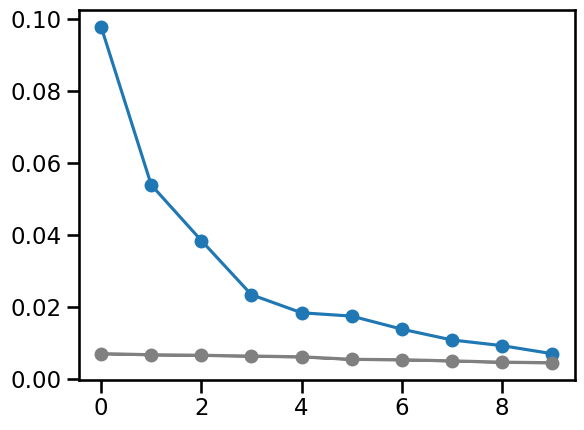

In [9]:
avg = np.mean(shuffled_evs, axis=0)
std = np.std(shuffled_evs, axis=0)

plt.plot(np.arange(10), pca.explained_variance_ratio_, '-o')
plt.plot(np.arange(10), avg, '-o', color='gray')
plt.fill_between(np.arange(10), 
                 avg-std, 
                 avg+std,
                 color='gray')

In [10]:
noc  = 3
ndim = noc-1
nrepeats = 3

In [11]:
# data 
sca.setup_feature_matrix(method='data')
xp, aa, _ = sca.proj_and_pcha(ndim, noc)
aa_boots = sca.bootstrap_proj_pcha(ndim, noc, nrepeats=nrepeats)

use data


## plot

In [12]:
types_colorvec = np.char.add('C', sca.types_idx.astype(str))

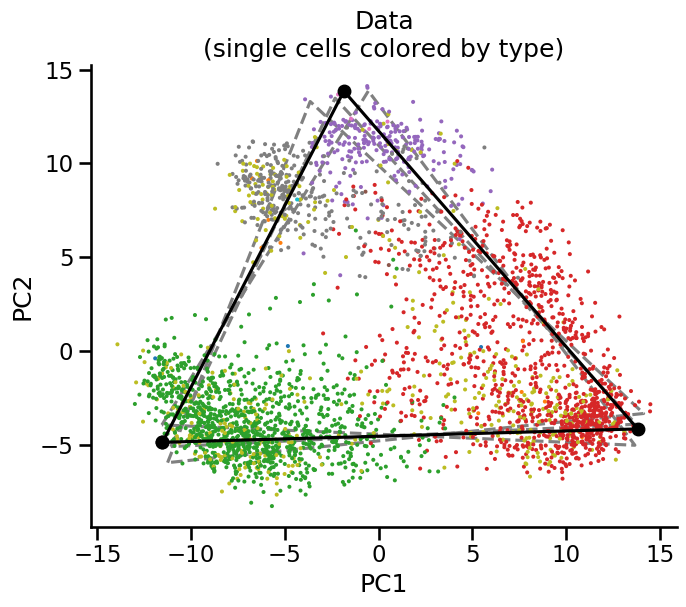

In [13]:
# plot
fig, ax = plt.subplots(1,1,figsize=(8*1,6))
ax.scatter(xp[:,0], xp[:,1], c=types_colorvec, s=2)
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_boots[i], fmt='--', color='gray', zorder=0)
ax.set_title('Data\n(single cells colored by type)')
    
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_aspect('equal')
sns.despine(ax=ax)
ax.grid(False)
    
plt.show()

In [14]:
subclass_colorvec = np.char.add('C', adata_hvg.obs.Subclass.cat.codes.astype(str))

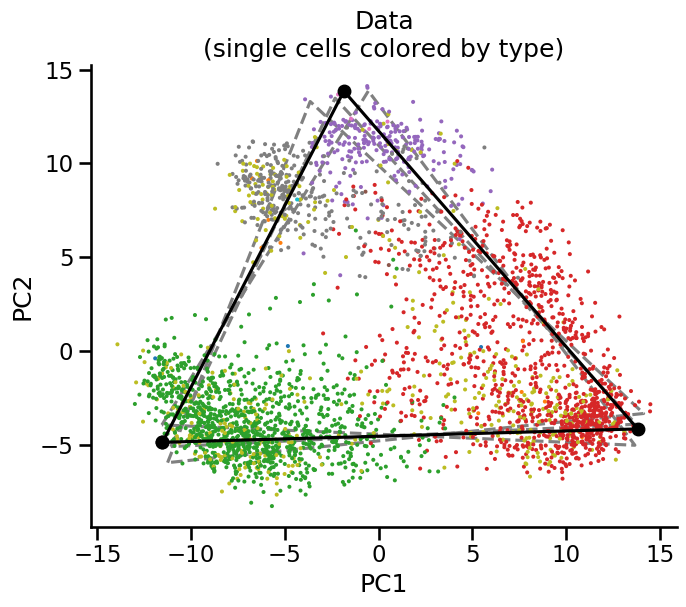

In [15]:
# plot
fig, ax = plt.subplots(1,1,figsize=(8*1,6))
ax.scatter(xp[:,0], xp[:,1], c=subclass_colorvec, s=2)
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_boots[i], fmt='--', color='gray', zorder=0)
ax.set_title('Data\n(single cells colored by type)')
    

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_aspect('equal')
sns.despine(ax=ax)
ax.grid(False)
    
plt.show()

# define a transcriptomic order

In [16]:
adata_dpt = adata_hvg
adata_dpt.obsm['pca_later'] = PCA(n_components=10).fit_transform(sca.xn)
adata_dpt

AnnData object with n_obs × n_vars = 3198 × 5071
    obs: 'cluster', 'Subclass'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'Subclass_colors', 'leiden', 'neighbors'
    obsm: 'X_pca', 'X_umap', 'my_pcs', 'my_ucs', 'rep', 'pca_later'
    layers: 'lognorm', 'zlognorm'
    obsp: 'connectivities', 'distances'

In [18]:
pc1 = adata_dpt.obsm['pca_later'][:,0]
pc2 = adata_dpt.obsm['pca_later'][:,1]
# gexp = np.array(adata_dpt[:,'Cdh13'].layers['norm']).reshape(-1,)

sc.pp.neighbors(adata_dpt, n_neighbors=30, use_rep='pca_later')
# adata_dpt.uns["iroot"] = np.argmax(gexp) 
adata_dpt.uns["iroot"] = np.argmin(pc1+pc2)
sc.tl.diffmap(adata_dpt)
sc.tl.dpt(adata_dpt)

In [20]:
num_bins = 50
xm = (1/2 + np.arange(0,num_bins,1))*1/num_bins
adata_dpt.obs['dpt'] = np.clip(adata_dpt.obs['dpt_pseudotime'].values, a_min=0, a_max=1)

adata_dpt.obs['dpt_bin']  = pd.cut( adata_dpt.obs['dpt'], num_bins, labels=False)
adata_dpt.obs['dpt_qbin'] = pd.qcut(adata_dpt.obs['dpt'], num_bins, labels=False)

cdf = adata_dpt.obs.groupby('dpt_bin').size()
cdf_by_subclass = adata_dpt.obs.groupby(['dpt_bin', 'Subclass']).size().unstack()
# cdf_by_type = adata_dpt.obs.groupby(['dpt_bin', 'Type']).size().unstack()

qcdf = adata_dpt.obs.groupby('dpt_qbin').size()
qcdf_by_subclass = adata_dpt.obs.groupby(['dpt_qbin', 'Subclass']).size().unstack()
# qcdf_by_type = adata_dpt.obs.groupby(['dpt_qbin', 'Type']).size().unstack()

Text(0.5, 1.0, 'Data\n(single cells colored by type)')

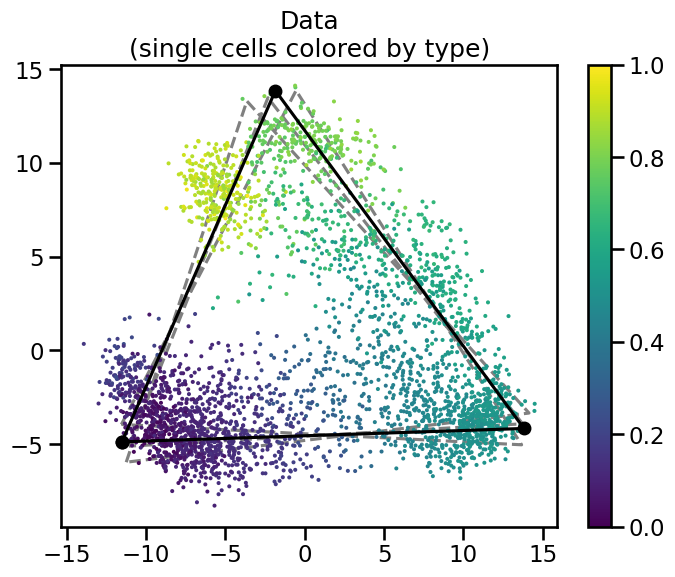

In [21]:
fig, ax = plt.subplots(1,1,figsize=(8*1,6))
g = ax.scatter(xp[:,0], xp[:,1], c=adata_dpt.obs['dpt'].values, s=2)
fig.colorbar(g)
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_boots[i], fmt='--', color='gray', zorder=0)
ax.set_title('Data\n(single cells colored by type)')

Text(0.5, 1.0, 'Data\n(single cells colored by type)')

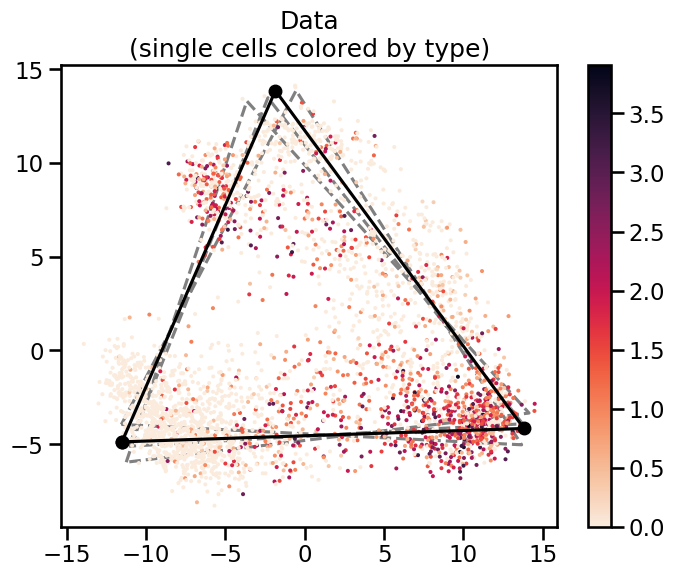

In [22]:
gexp = np.array(adata_dpt[:,'Chrm2'].layers['lognorm']).reshape(-1,)

fig, ax = plt.subplots(1,1,figsize=(8*1,6))
g = ax.scatter(xp[:,0], xp[:,1], c=gexp, s=2, cmap='rocket_r')
fig.colorbar(g)
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_boots[i], fmt='--', color='gray', zorder=0)
ax.set_title('Data\n(single cells colored by type)')

# 3D plot

In [23]:
pcs = PCA(n_components=5).fit_transform(adata_hvg.layers['lognorm'][...])

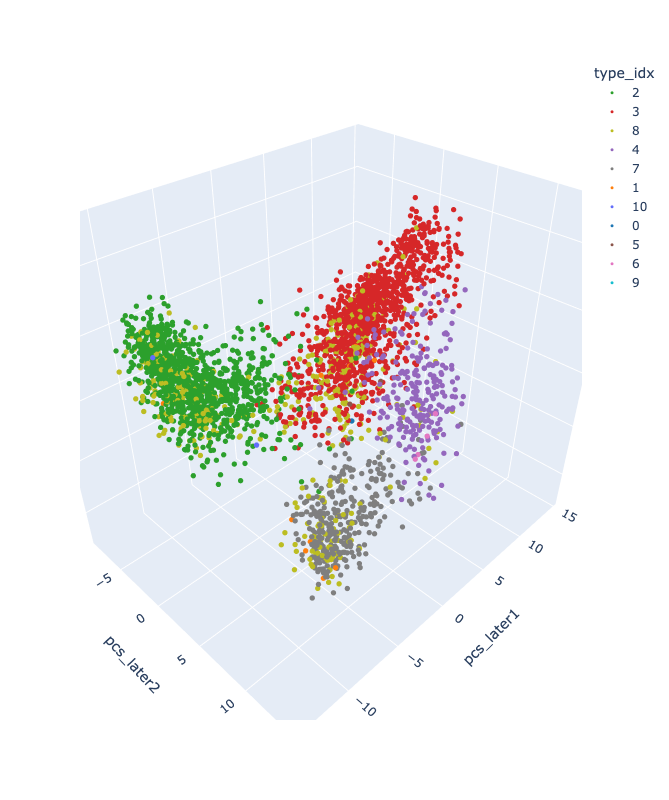

In [24]:
import plotly.express as px

mpl_colors = {
    '0': '#1f77b4', '1': '#ff7f0e', '2': '#2ca02c', '3': '#d62728', '4': '#9467bd',
    '5': '#8c564b', '6': '#e377c2', '7': '#7f7f7f', '8': '#bcbd22', '9': '#17becf'
}

df = pd.DataFrame()
df['pcs_later1'] = pcs[:,0]
df['pcs_later2'] = pcs[:,1]
df['pcs_later3'] = pcs[:,2]
df['type_idx'] = sca.types_idx.astype(str)

fig = px.scatter_3d(df, x='pcs_later1', y='pcs_later2', z='pcs_later3',
                      color='type_idx', 
                      color_discrete_map=mpl_colors,
                   )
fig.update_traces(marker_size=3) 
fig.update_layout(width=1000, height=800)

fig.update_scenes(xaxis_autorange="reversed") 
fig.update_layout(scene_dragmode='orbit')
fig.show()


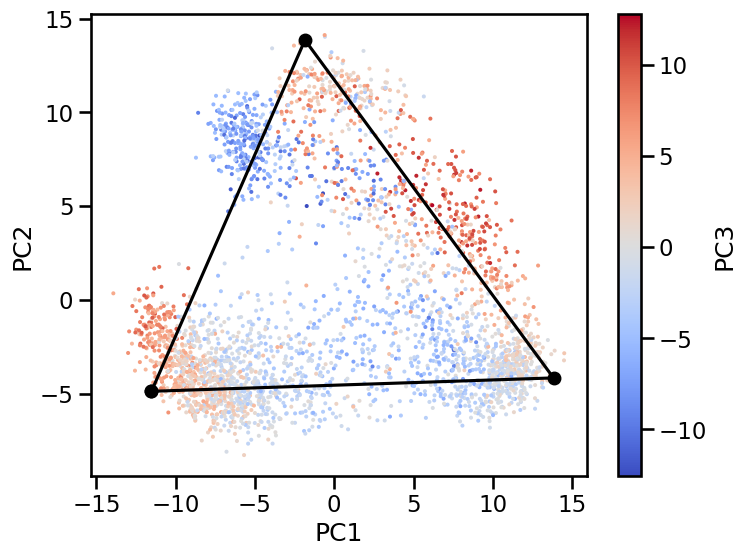

In [25]:
fig, ax = plt.subplots(1,1,figsize=(8*1,6))
g = ax.scatter(df['pcs_later1'], 
               df['pcs_later2'],
               c=df['pcs_later3'], s=2, cmap='coolwarm')
fig.colorbar(g, label='PC3')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)

# gene expression as a function of the order
- for all genes 

In [32]:
adata_dpt

AnnData object with n_obs × n_vars = 3198 × 5071
    obs: 'cluster', 'Subclass', 'dpt_pseudotime', 'dpt', 'dpt_bin', 'dpt_qbin'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'Subclass_colors', 'leiden', 'neighbors', 'iroot', 'diffmap_evals'
    obsm: 'X_pca', 'X_umap', 'my_pcs', 'my_ucs', 'rep', 'pca_later', 'X_diffmap'
    layers: 'lognorm', 'zlognorm'
    obsp: 'connectivities', 'distances'

In [35]:
# get all info
mat = adata_dpt.layers['lognorm']
df = pd.DataFrame(mat, columns=adata_dpt.var.index, index=adata_dpt.obs.index)
df['dpt'] = adata_dpt.obs['dpt']
df['dpt_bin'] = adata_dpt.obs['dpt_bin']
df['dpt_qbin'] = adata_dpt.obs['dpt_qbin']
yms = df.groupby('dpt_bin').mean()
qyms = df.groupby('dpt_qbin').mean()

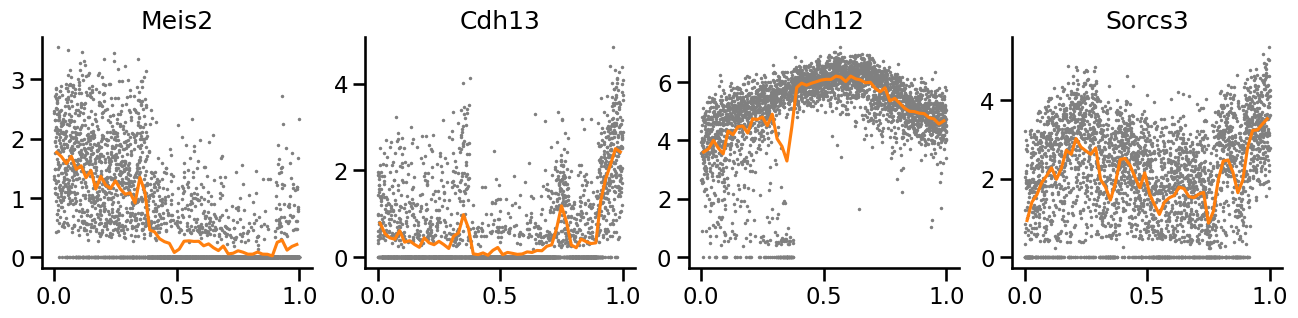

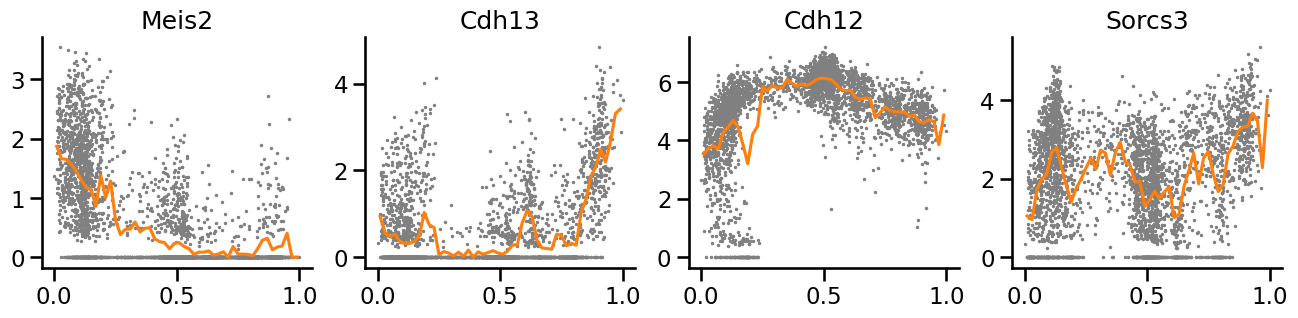

In [38]:
x  = adata_dpt.obs['dpt']
qx = adata_dpt.obs['dpt'].rank(pct=True)

gns = ['Meis2', 
       # 'Rfx3', 
       'Cdh13', 'Cdh12', 'Sorcs3',]
n = len(gns)

fig, axs = plt.subplots(1,n,figsize=(n*4,1*3))
for i, gn in enumerate(gns):
    ax = axs[i]
    
    y = np.array(adata_dpt[:,gn].layers['lognorm']).reshape(-1,)
    ax.scatter(qx, y, s=1, color='gray')
    
    ax.plot(xm, qyms[gn], color='C1')
    
    sns.despine(ax=ax)
    ax.set_title(gn)
plt.show()

fig, axs = plt.subplots(1,n,figsize=(n*4,1*3))
for i, gn in enumerate(gns):
    ax = axs[i]
    
    y = np.array(adata_dpt[:,gn].layers['lognorm']).reshape(-1,)
    ax.scatter(x, y, s=1, color='gray')
    
    ax.plot(xm, yms[gn], color='C1')
    
    sns.despine(ax=ax)
    ax.set_title(gn)
plt.show()

# cell density along dpt as a control

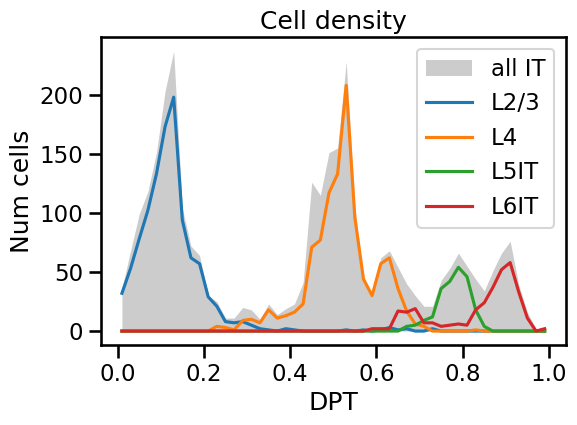

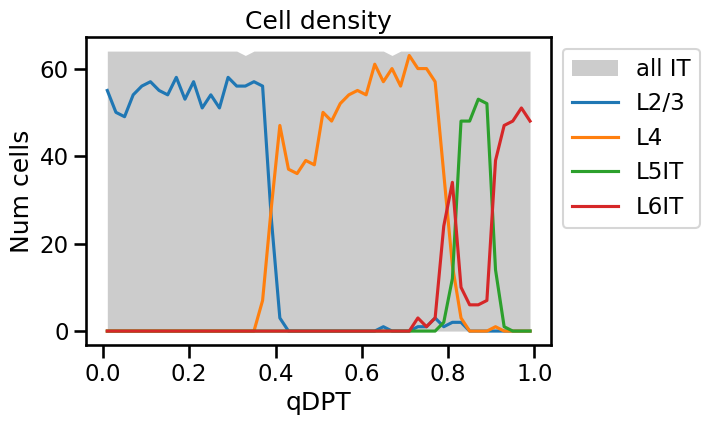

In [39]:
fig, ax = plt.subplots(figsize=(6,4))
ax.fill_between(xm, 0, cdf, color='k', label='all IT', alpha=0.2, linewidth=0)
subclasses = ['L2/3', 'L4', 'L5IT', 'L6IT']
for subclass in subclasses:
    ax.plot(xm, cdf_by_subclass[subclass], label=subclass)
ax.legend(bbox_to_anchor=(1,1))
ax.set_title('Cell density')
ax.set_xlabel('DPT')
ax.set_ylabel('Num cells')
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
ax.fill_between(xm, 0, qcdf, color='k', label='all IT', alpha=0.2, linewidth=0)
subclasses = ['L2/3', 'L4', 'L5IT', 'L6IT']
for subclass in subclasses:
    ax.plot(xm, qcdf_by_subclass[subclass], label=subclass)
ax.legend(bbox_to_anchor=(1,1))
ax.set_title('Cell density')
ax.set_xlabel('qDPT')
ax.set_ylabel('Num cells')
plt.show()

NameError: name 'cdf_by_type' is not defined

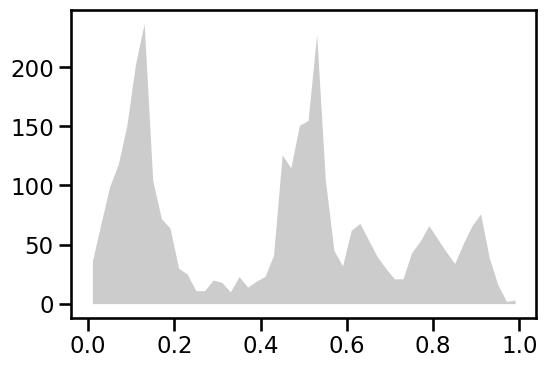

In [40]:
# fig, ax = plt.subplots(figsize=(6,4))
# ax.fill_between(xm, 0, cdf, color='k', label='all IT', alpha=0.2, linewidth=0)
# for subclass in cdf_by_type.columns:
#     ax.plot(xm, cdf_by_type[subclass], label=subclass)
# ax.legend(bbox_to_anchor=(1,1))
# ax.set_title('Cell density')
# ax.set_xlabel('DPT')
# ax.set_ylabel('Num cells')
# plt.show()

# fig, ax = plt.subplots(figsize=(6,4))
# ax.fill_between(xm, 0, qcdf, color='k', label='all IT', alpha=0.2, linewidth=0)
# for subclass in qcdf_by_type.columns:
#     ax.plot(xm, qcdf_by_type[subclass], label=subclass)
# ax.legend(bbox_to_anchor=(1,1))
# ax.set_title('Cell density')
# ax.set_xlabel('qDPT')
# ax.set_ylabel('Num cells')
# plt.show()